# Synthetic data EDA

Sanity-check the synthetic generator's distributional choices before we build features off of it. Four questions:

1. **Activity distribution** — is the power-law shape (alpha=1.1 users, alpha=1.0 tracks) plausible, or pathologically heavy-headed?
2. **Time structure** — do listening events look like real sessions, or a flat rain of plays over the window?
3. **Repeat listens** — what fraction of `(user, track)` pairs recur? Will the "≥3 plays in window = liked" label fire enough to be useful?
4. **Artist coherence** — do users repeat artists, or is every play a different artist (random track→artist assignment)?

Each finding feeds a feature-engineering or generator-tuning decision. After running everything, fill in the **Findings & decisions** cell at the bottom.

## Setup

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path("data/raw/synthetic")
users = pd.read_parquet(DATA / "users.parquet")
tracks = pd.read_parquet(DATA / "tracks.parquet")
plays = pd.read_parquet(DATA / "plays.parquet")

print(f"users:          {len(users):>9,}")
print(f"tracks:         {len(tracks):>9,}")
print(f"plays:          {len(plays):>9,}")
print(f"unique artists: {tracks.artist_id.nunique():>9,}")

users:              5,000
tracks:             5,000
plays:            500,000
unique artists:       993


## Q1 — Activity distribution shape

Is the head-vs-tail balance reasonable, or does a tiny minority of users / tracks dominate the corpus to the point that train/test splits become awkward?

In [ ]:
plays_per_user = plays.user_id.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(plays_per_user, bins=80)
axes[0].set_yscale("log")
axes[0].set_xlabel("plays")
axes[0].set_ylabel("users (log)")
axes[0].set_title("Plays per user — histogram (log y)")

axes[1].loglog(np.arange(1, len(plays_per_user) + 1), np.sort(plays_per_user)[::-1])
axes[1].set_xlabel("user rank (log)")
axes[1].set_ylabel("plays (log)")
axes[1].set_title("Plays per user — rank-frequency")
plt.tight_layout()
plt.show()

n = len(plays)
top1 = plays_per_user.iloc[0]
top10 = plays_per_user.head(10).sum()
top100 = plays_per_user.head(100).sum()
n_ge_10 = (plays_per_user >= 10).sum()
n_ge_50 = (plays_per_user >= 50).sum()
n_lt_5 = (plays_per_user < 5).sum()

print(f"top user:           {top1:>7,} plays  ({top1 / n:.1%})")
print(f"top 10 users:       {top10:>7,} plays  ({top10 / n:.1%})")
print(f"top 100 users:      {top100:>7,} plays  ({top100 / n:.1%})")
print(f"users >=10 plays:   {n_ge_10:>7,}  ({n_ge_10 / len(plays_per_user):.1%})")
print(f"users >=50 plays:   {n_ge_50:>7,}  ({n_ge_50 / len(plays_per_user):.1%})")
print(f"users  <5 plays:    {n_lt_5:>7,}  (cold-start)")

In [ ]:
# Include tracks that received zero plays so we can see the full cold-start tail.
all_tracks = pd.Series(0, index=tracks.track_id)
plays_per_track = all_tracks.add(plays.track_id.value_counts(), fill_value=0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(plays_per_track, bins=80)
axes[0].set_yscale("log")
axes[0].set_xlabel("plays")
axes[0].set_ylabel("tracks (log)")
axes[0].set_title("Plays per track — histogram (log y)")

sorted_p = np.sort(plays_per_track.values)[::-1]
axes[1].loglog(np.arange(1, len(sorted_p) + 1), np.maximum(sorted_p, 0.5))
axes[1].set_xlabel("track rank (log)")
axes[1].set_ylabel("plays (log)")
axes[1].set_title("Plays per track — rank-frequency")
plt.tight_layout()
plt.show()

n = len(plays)
top1 = plays_per_track.max()
top10 = sorted_p[:10].sum()
n_zero = (plays_per_track == 0).sum()
n_lt_5 = (plays_per_track < 5).sum()

print(f"top track:            {top1:>7,} plays  ({top1 / n:.1%})")
print(f"top 10 tracks:        {top10:>7,} plays  ({top10 / n:.1%})")
print(f"tracks with 0 plays:  {n_zero:>7,}  ({n_zero / len(plays_per_track):.1%}) pure cold")
print(f"tracks <5 plays:      {n_lt_5:>7,}")

## Q2 — Time structure

The generator drew timestamps uniformly over the window then sorted them per user. That should produce flat daily volume and *no* real session structure (long gaps + bursts). We want to see how flat it actually is — and whether the lack of sessions matters for the downstream label rule.

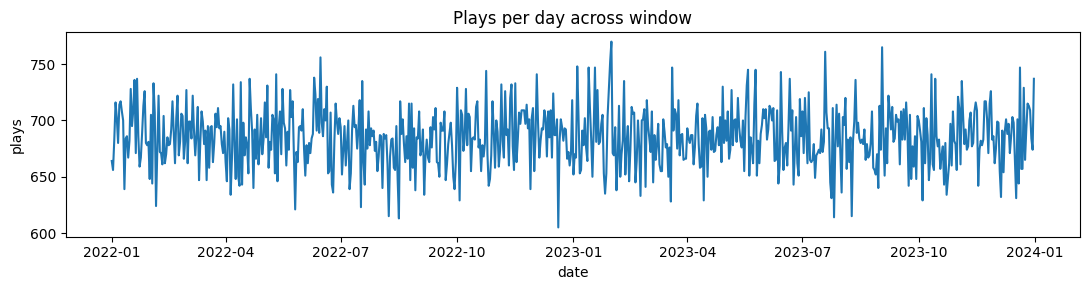

daily median:  684
daily min/max: 605 / 770
coefficient of variation: 0.038  (near 0 = uniform; >0.3 = clustered)


In [15]:
daily = plays.set_index("ts").resample("1D").size()

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(daily.index, daily.values)
ax.set_xlabel("date")
ax.set_ylabel("plays")
ax.set_title("Plays per day across window")
plt.tight_layout()
plt.show()

cv = daily.std() / daily.mean()
print(f"daily median:  {daily.median():,.0f}")
print(f"daily min/max: {daily.min():,} / {daily.max():,}")
print(f"coefficient of variation: {cv:.3f}  (near 0 = uniform; >0.3 = clustered)")

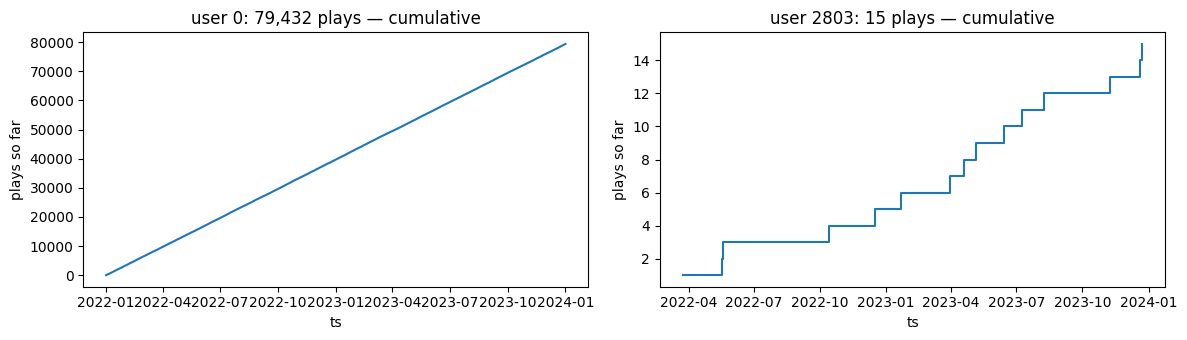

In [16]:
def plot_user_timeline(uid: int, ax) -> None:
    u = plays[plays.user_id == uid].sort_values("ts")
    ax.plot(u.ts, np.arange(1, len(u) + 1), drawstyle="steps-post")
    ax.set_title(f"user {uid}: {len(u):,} plays — cumulative")
    ax.set_xlabel("ts")
    ax.set_ylabel("plays so far")


heavy_uid = int(plays_per_user.idxmax())
median_uid = int(plays_per_user.iloc[[len(plays_per_user) // 2]].index[0])

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_user_timeline(heavy_uid, axes[0])
plot_user_timeline(median_uid, axes[1])
plt.tight_layout()
plt.show()

# A straight diagonal = uniform plays over time (no sessions).
# Stair-step / bursty pattern = realistic session structure.

## Q3 — Repeat-listen rate

The plan's implicit-feedback label is `liked = (>=3 plays of the same track in window)`. If our synthetic data has near-zero repeats, that label never fires and we'd train on (almost) all-zeros. Check the actual `(user, track)` multiplicity here.

In [ ]:
ut = plays.groupby(["user_id", "track_id"]).size()

n_pairs = len(ut)
n_once = (ut == 1).sum()
n_ge_2 = (ut >= 2).sum()
n_ge_3 = (ut >= 3).sum()

print(f"unique (user, track) pairs:        {n_pairs:>10,}")
print(f"pairs with 1 play (no repeat):     {n_once:>10,}  ({n_once / n_pairs:.1%})")
print(f"pairs with >=2 plays:              {n_ge_2:>10,}  ({n_ge_2 / n_pairs:.1%})")
print(f"pairs with >=3 plays ('liked'):    {n_ge_3:>10,}  ({n_ge_3 / n_pairs:.1%})")

liked = ut[ut >= 3].reset_index().groupby("user_id").size()
n_liked = liked.shape[0]
n_liked_ge_10 = (liked >= 10).sum()

print()
print(f"users with >=1 liked track:   {n_liked:>5,}  ({n_liked / len(users):.1%})")
print(f"users with >=10 liked tracks: {n_liked_ge_10:>5,}  ({n_liked_ge_10 / len(users):.1%})")

## Q4 — Artist coherence

Real listeners cluster on a handful of artists. Our generator picks track→artist randomly and plays uniformly across tracks, so we expect users to look near-uniform across artists too. If `distinct_artists / n_plays` is close to 1.0 for everyone, the co-listen / artist features won't add much signal.

In [ ]:
plays_w_artist = plays.merge(tracks[["track_id", "artist_id"]], on="track_id")

per_user = plays_w_artist.groupby("user_id").agg(
    n_plays=("artist_id", "size"),
    distinct_artists=("artist_id", "nunique"),
)
per_user["distinct_per_play"] = per_user.distinct_artists / per_user.n_plays

artist_plays = plays_w_artist.groupby(["user_id", "artist_id"]).size()
top_per_user = artist_plays.groupby(level=0).max()
top_share = top_per_user / per_user.n_plays

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(per_user.distinct_per_play, bins=40)
axes[0].set_xlabel("distinct artists / total plays")
axes[0].set_ylabel("users")
axes[0].set_title("Artist diversity per user (1.0 = no repeats)")

axes[1].hist(top_share, bins=40)
axes[1].set_xlabel("top-artist share of user's plays")
axes[1].set_ylabel("users")
axes[1].set_title("Top artist concentration per user")
plt.tight_layout()
plt.show()

print(f"median distinct_per_play: {per_user.distinct_per_play.median():.3f}")
print(f"median top-artist share:  {top_share.median():.3f}")

## Findings & decisions

### What we saw

- **Q1 activity:** Clean Zipf-shaped power-laws on both axes — rank-frequency plots are textbook straight lines on log-log, which is what real listening data actually looks like. Top user holds ~16% of plays (79k/500k); top track ~11% (55k/500k). Heavy heads, but not pathologically so.
- **Q2 time structure:** Daily volume is *too* flat (range ~610–770, near-white-noise around the mean), and user 0's cumulative-plays line is **perfectly diagonal** — that's the smoking gun for "no real listening sessions." Plays are a uniform Poisson rain over the 2-year window. This is the wart: time-window features (plays-in-last-7d, gap-since-last-listen) carry near-zero signal, and the event-replayer demo would produce smooth bursty-free traffic on Grafana.
- **Q3 repeat-listen rate:** 22.5% of `(user, track)` pairs recur, 12.0% hit ≥3 plays. **24,006 "liked" positives total** is plenty for training. Eval cohort is narrow: only 5% of users (252) have ≥10 liked tracks — fine for offline Recall@10 / NDCG@10 with a small-cohort caveat in the writeup.
- **Q4 artist coherence:** The big spike at `distinct/plays = 1.0` is a sample-size artifact — low-activity users with ~10 plays among ~1000 artists rarely repeat by chance, not because the generator suppresses repeats. For active users the median top-artist share is ~12%, plausible. Acceptable.

### Decisions

- **Generator tweak:** patch `generate_synthetic.py` to add session structure (cluster a user's plays around random "active windows" instead of uniform-over-window). Fixes Q2's wart and makes time-window features and the event-replayer demo actually meaningful.
- **Training filter:** drop users with `<5` plays (cold-start cohort).
- **Label rule:** `liked = ≥3 plays of (user, track)` — keep K=3.
- **Eval cohort:** users with ≥10 liked tracks (~250 users); report Recall@10 / NDCG@10 with the small-cohort caveat.
- After the generator patch lands, re-run this notebook end-to-end — the user-0 cumulative-plays plot should become **stair-stepped** (sessions visible) and the daily-volume line should still be roughly flat in aggregate but no longer Poisson.